In [1]:
from pathlib import Path
import sys

# Определяем корень проекта:
# если ноутбук запущен из notebooks/ — это родитель, иначе — текущая папка
CWD = Path.cwd()
PROJECT_ROOT = CWD.parent if CWD.name == "notebooks" else CWD

# Делаем корень доступным для импорта data_loader
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("CWD:          ", CWD)
print("PROJECT_ROOT: ", PROJECT_ROOT)
print("CSV exists:   ", (PROJECT_ROOT / "predictive_maintenance_v3.csv").exists())

CWD:           C:\Users\User\PycharmProjects\Industrial-Dataset\notebooks
PROJECT_ROOT:  C:\Users\User\PycharmProjects\Industrial-Dataset
CSV exists:    True


In [2]:
from data_loader import load_data, cast_types, LOCAL_FILE_NAME

# Если файла нет — скачаем его через data_loader
if not LOCAL_FILE_NAME.exists():
    import data_loader
    data_loader.download_file(data_loader.YANDEX_DISK_URL, LOCAL_FILE_NAME)

df = cast_types(load_data(LOCAL_FILE_NAME))
df.head()

,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24042 entries, 0 to 24041
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   timestamp                24042 non-null  datetime64[us]
 1   machine_id               24042 non-null  int64         
 2   machine_type             24042 non-null  category      
 3   vibration_rms            23042 non-null  float64       
 4   temperature_motor        23208 non-null  float64       
 5   current_phase_avg        23311 non-null  float64       
 6   pressure_level           23118 non-null  float64       
 7   rpm                      23509 non-null  float64       
 8   operating_mode           24042 non-null  category      
 9   hours_since_maintenance  24042 non-null  float64       
 10  ambient_temp             24042 non-null  float64       
 11  rul_hours                24042 non-null  float64       
 12  failure_within_24h       24042 non-null  in

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
timestamp,24042,NaN,NaN,NaN,2024-01-08 00:06:30.111721,2024-01-01 00:00:00,2024-01-04 12:24:13.750000,2024-01-08 00:11:30,2024-01-11 13:24:32.500000,2024-01-14 23:59:38,NaN
machine_id,24042.0,NaN,NaN,NaN,10.505033,1.0,6.0,10.0,15.0,20.0,5.746455
machine_type,24042,4,Pump,6114,NaN,NaN,NaN,NaN,NaN,NaN,NaN
vibration_rms,23042.0,NaN,NaN,NaN,1.623667,0.35,0.82,1.27,2.27,10.0,1.081061
temperature_motor,23208.0,NaN,NaN,NaN,51.404295,28.0,42.61,50.06,59.9625,95.0,12.519279
current_phase_avg,23311.0,NaN,NaN,NaN,8.823829,2.2,4.63,6.43,13.12,35.0,5.366391
pressure_level,23118.0,NaN,NaN,NaN,59.012233,10.1,22.7,46.3,94.7,206.5,38.723271
rpm,23509.0,NaN,NaN,NaN,1144.849317,124.1,489.4,856.0,1676.0,4098.8,912.670971
operating_mode,24042,3,normal,11632,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hours_since_maintenance,24042.0,NaN,NaN,NaN,172.630624,0.0,42.87,121.61,295.575,575.63,150.722469


In [5]:
df.isna().sum().sort_values(ascending=False)

vibration_rms              1000
pressure_level              924
temperature_motor           834
current_phase_avg           731
rpm                         533
timestamp                     0
machine_type                  0
machine_id                    0
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_within_24h            0
failure_type                  0
estimated_repair_cost         0
dtype: int64

In [6]:
df.isna().mean().sort_values(ascending=False) * 100

vibration_rms              4.159388
pressure_level             3.843274
temperature_motor          3.468929
current_phase_avg          3.040512
rpm                        2.216954
timestamp                  0.000000
machine_type               0.000000
machine_id                 0.000000
operating_mode             0.000000
hours_since_maintenance    0.000000
ambient_temp               0.000000
rul_hours                  0.000000
failure_within_24h         0.000000
failure_type               0.000000
estimated_repair_cost      0.000000
dtype: float64


=== machine_type ===
machine_type
Pump           6114
Robotic Arm    6003
Compressor     5988
CNC            5937
Name: count, dtype: int64

=== operating_mode ===
operating_mode
normal    11632
idle      10862
peak       1548
Name: count, dtype: int64

=== failure_type ===
failure_type
none              20482
bearing            1117
motor_overheat     1060
hydraulic           728
electrical          655
Name: count, dtype: int64


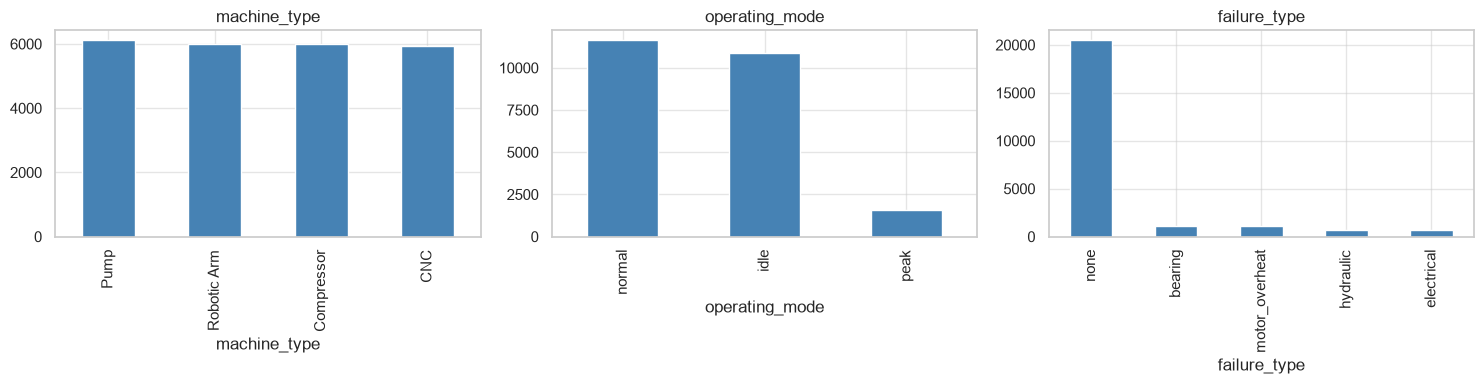

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["machine_type", "operating_mode", "failure_type"]):
    print(f"\n=== {col} ===")
    print(df[col].value_counts(dropna=False))
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [8]:
df.groupby("machine_type", observed=True)["rul_hours"].describe()

,count,mean,std,min,25%,50%,75%,max
machine_type,,,,,,,,
CNC,5937.0,27.417650,26.993932,0.5,0.5000,21.13,47.120,98.34
Compressor,5988.0,31.174574,25.768966,0.5,6.8875,28.15,48.870,96.39
Pump,6114.0,26.545994,25.590306,0.5,0.5000,21.57,44.525,95.66
Robotic Arm,6003.0,26.139300,26.916191,0.5,0.5000,18.30,45.250,94.06


In [9]:
df.groupby("machine_type", observed=True)["machine_id"].nunique()

machine_type
CNC            5
Compressor     5
Pump           5
Robotic Arm    5
Name: machine_id, dtype: int64

In [10]:
df.groupby("failure_type", observed=True)["estimated_repair_cost"].describe()

,count,mean,std,min,25%,50%,75%,max
failure_type,,,,,,,,
bearing,1117.0,3734.051925,728.29099,2500.0,3078.0,3729.0,4362.0,4997.0
electrical,655.0,4043.096183,1162.856676,2002.0,3042.5,4071.0,5060.5,5992.0
hydraulic,728.0,2726.311813,737.498646,1502.0,2064.5,2689.5,3379.25,3998.0
motor_overheat,1060.0,5504.280189,1457.799928,3007.0,4228.75,5540.0,6764.25,7995.0
none,20482.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [11]:
df["failure_within_24h"].value_counts()

failure_within_24h
0    20482
1     3560
Name: count, dtype: int64

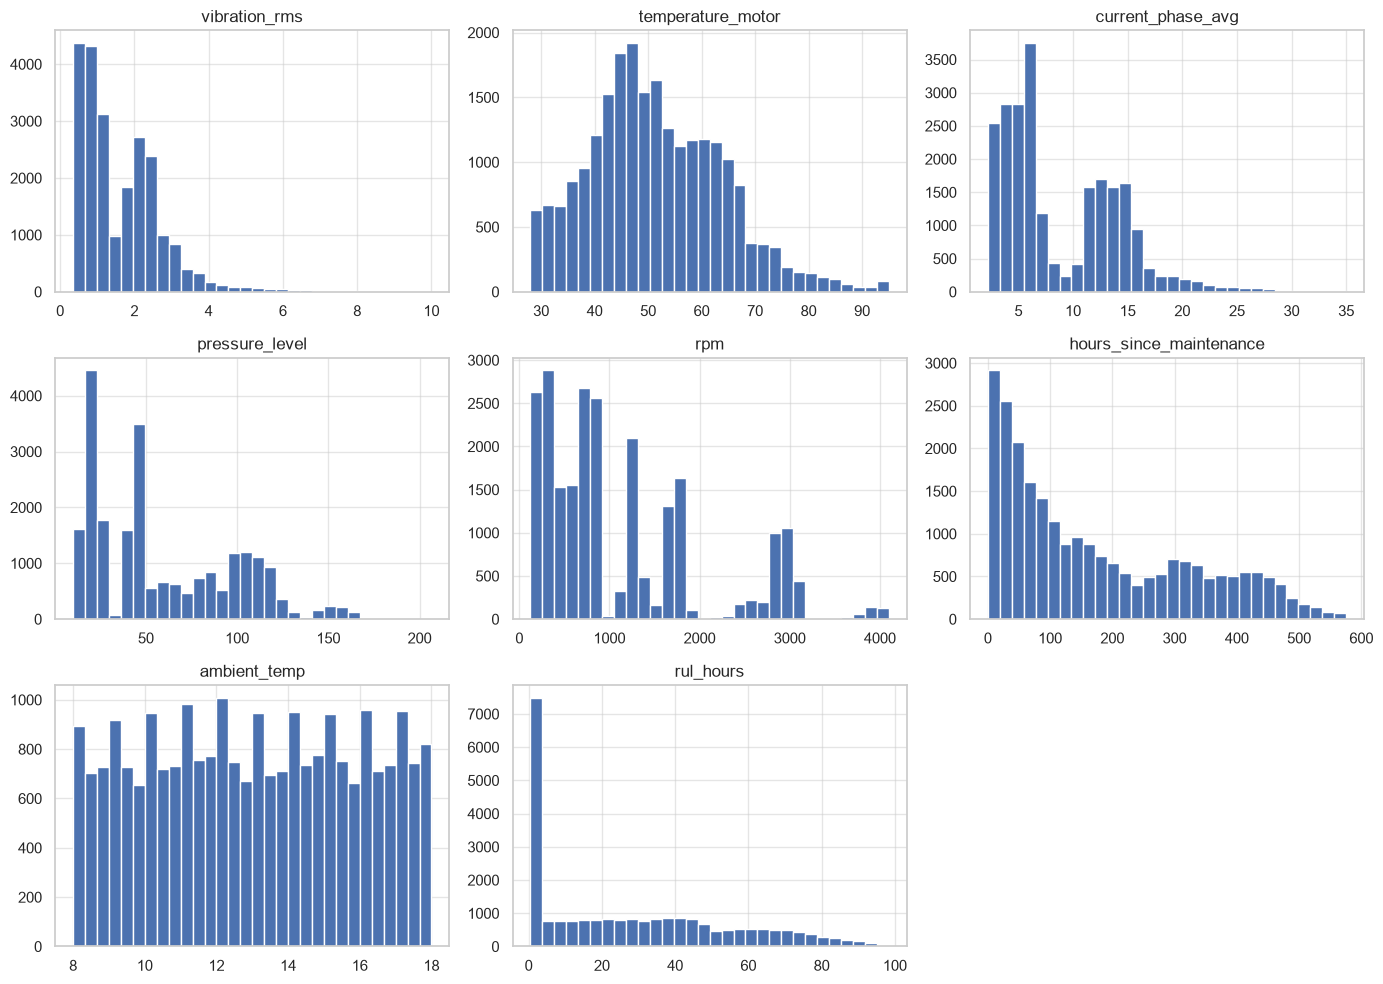

In [12]:
num_cols = [
    "vibration_rms", "temperature_motor", "current_phase_avg",
    "pressure_level", "rpm", "hours_since_maintenance",
    "ambient_temp", "rul_hours",
]
df[num_cols].hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [13]:
from data_loader import save_parquet, PARQUET_FILE_NAME

save_parquet(df, PARQUET_FILE_NAME)

Parquet сохранён: C:\Users\User\PycharmProjects\Industrial-Dataset\predictive_maintenance_v3.parquet
